In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pandas
!pip install scikit-learn
!pip install joblib

In [3]:
import pandas as pd
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv(
    "/content/drive/MyDrive/SmartRetailAI/datasets/reviews.csv"
)

In [5]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [6]:
print(df.shape)

df.info()

df.head()

(23486, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Remove rows where review text is missing
df = df.dropna(subset=["Review Text"])

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Review Text"])

y = df["Recommended IND"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [11]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8900419518657541


In [13]:
import joblib

joblib.dump(
    model,
    "/content/drive/MyDrive/SmartRetailAI/models/sentiment_model.pkl"
)

joblib.dump(
    vectorizer,
    "/content/drive/MyDrive/SmartRetailAI/models/vectorizer.pkl"
)

['/content/drive/MyDrive/SmartRetailAI/models/vectorizer.pkl']

In [14]:
review = ["This dress is beautiful and fits perfectly."]

review_vector = vectorizer.transform(review)

prediction = model.predict(review_vector)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

Positive Review 😊


In [15]:
review = ["Very poor quality. Waste of money."]

review_vector = vectorizer.transform(review)

prediction = model.predict(review_vector)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

Negative Review 😞


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.78      0.53      0.64       812
           1       0.90      0.97      0.94      3717

    accuracy                           0.89      4529
   macro avg       0.84      0.75      0.79      4529
weighted avg       0.88      0.89      0.88      4529

[[ 434  378]
 [ 120 3597]]


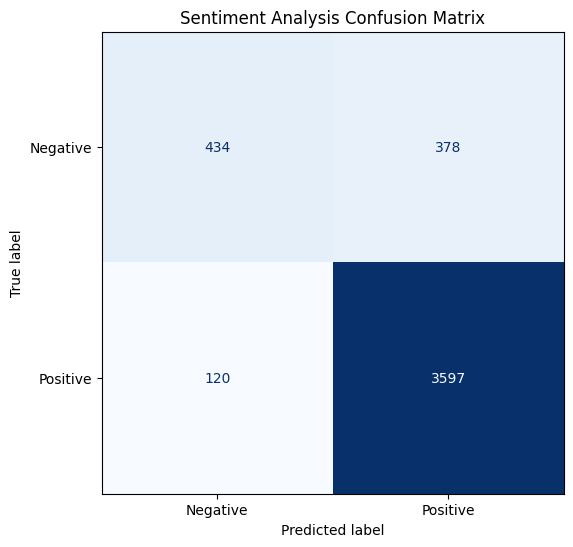

Confusion matrix saved to:
/content/drive/MyDrive/SmartRetailAI/outputs/sentiment_confusion_matrix.png


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

# Create outputs directory if it doesn't exist
os.makedirs("/content/drive/MyDrive/SmartRetailAI/outputs", exist_ok=True)

# Generate confusion matrix
cm = confusion_matrix(y_test, pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax, colorbar=False)

plt.title("Sentiment Analysis Confusion Matrix")

# Save the figure
save_path = "/content/drive/MyDrive/SmartRetailAI/outputs/sentiment_confusion_matrix.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Confusion matrix saved to:\n{save_path}")